# Análise e visualização — Protocolo ENMC ($K_{ref}$ guiando R-NSGA-II e PI-NSGA-II)

Lê os CSVs gerados pelo experimento (`Pesquisa_ENMC_KneeRef.ipynb`) e produz **tabelas e figuras em qualidade de publicação**. Não re-executa nada.

Entregas (conforme orientação):
1. **Duas tabelas** — 21 distâncias knee→ideal do R-NSGA-II e do PI-NSGA-II, com média, desvio-padrão, mínimo e máximo, + **Wilcoxon pareado** (sementes casadas).
2. **Boxplots** das distribuições.
3. **Curvas de Pareto** de cada problema com $K_{ref}$, os 21 knees obtidos e o ponto ideal.
4. **Concentração** em torno de $K_{ref}$ (refinamento do orientador: posição do knee ≠ concentração da população).
5. **Caixinha** (região de interesse em torno do ideal): HV e IGD dentro dela (extensão sugerida).
6. Descrição dos problemas.

## 0. Configuração e estilo de publicação

In [1]:
#!pip install -q pymoo seaborn

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon
from pathlib import Path
from IPython.display import display

# ---------------- estilo de publicação ----------------
sns.set_theme(context="paper", style="whitegrid")
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300, "savefig.bbox": "tight", "savefig.format": "pdf",
    "font.family": "serif", "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11,
    "legend.fontsize": 9, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "pdf.fonttype": 42, "ps.fonttype": 42,
})
# Paleta ÚNICA do artigo (Okabe-Ito: segura p/ daltônicos, legível em P&B).
# Não redefinir COR em nenhuma outra célula.
COR = {"NSGA-II": "#9E9E9E", "R-NSGA-II": "#0072B2", "PI-NSGA-II": "#D55E00"}
C_REF   = "#BDBDBD"   # P_ref ao fundo
C_KNEE  = "#000000"   # knees por execução
C_KREF  = "#E7298A"   # K_ref
C_IDEAL = "#E0A300"   # ponto ideal
PASTA_FIG = Path("figuras"); PASTA_FIG.mkdir(exist_ok=True)

def salvar(fig, nome):
    p = PASTA_FIG / f"{nome}.pdf"; fig.savefig(p); print("salvo:", p)

# ---------------- arquivos do experimento ----------------
SUFIXO  = "pop100_gen300_runs21"          # <-- ajuste se mudou os parâmetros
CSV_F1  = f"enmc_fase1_nsga2_{SUFIXO}.csv"
CSV_F2  = f"enmc_fase2_rnsga2_{SUFIXO}.csv"
CSV_F3  = f"enmc_fase3_pinsga2_{SUFIXO}.csv"
CSV_REF = f"enmc_referencias_{SUFIXO}.csv"

## Funções de análise

In [4]:
# Funções de análise (as mesmas do experimento — reconstroem tudo do CSV)

def filtrar_nao_dominados(F):
    F = np.asarray(F, float)
    keep = np.ones(len(F), bool)
    for i in range(len(F)):
        if keep[i]:
            dom = np.all(F <= F[i], axis=1) & np.any(F < F[i], axis=1)
            if dom.any(): keep[i] = False
    return F[keep]

def normalizar(F, F_min, F_max):
    return (np.atleast_2d(F) - F_min) / (F_max - F_min + 1e-12)

def knee_point(F):
    F = np.atleast_2d(F)
    n_pts, n_obj = F.shape
    if n_pts <= 2: return F[0]
    Fmin, Fmax = F.min(0), F.max(0)
    Fn = (F - Fmin) / (Fmax - Fmin + 1e-12)
    extremos = Fn[np.argmin(Fn, axis=0)]
    try:
        a, *_  = np.linalg.lstsq(extremos, np.ones(n_obj), rcond=None)
        norm_a = np.linalg.norm(a)
        if not np.isfinite(norm_a) or norm_a < 1e-12:
            raise np.linalg.LinAlgError
        knee_idx = int(np.argmax(np.abs(Fn @ a - 1.0) / norm_a))
    except np.linalg.LinAlgError:
        knee_idx = int(np.argmin(np.linalg.norm(Fn - 0.5, axis=1)))
    return F[knee_idx]

print("Funções de análise definidas")

Funções de análise definidas


## Carregar CSVs e reconstruir o experimento

In [5]:
# ================= Carregar CSVs e reconstruir o experimento =================
def _frentes_por_run(df, nome, alg):
    sub = df[(df["problema"] == nome) & (df["algoritmo"] == alg)]
    if sub.empty: return None
    d = 3 if sub["f3"].notna().any() else 2
    cols = ["f1", "f2", "f3"][:d]
    return [g[cols].to_numpy(float) for _, g in sub.groupby("run")]

df1, df2, df3 = pd.read_csv(CSV_F1), pd.read_csv(CSV_F2), pd.read_csv(CSV_F3)
refs = pd.read_csv(CSV_REF)
PROBLEMAS = list(df1["problema"].unique())

exp = {}
for nome in PROBLEMAS:
    f1 = _frentes_por_run(df1, nome, "NSGA-II")
    f2 = _frentes_por_run(df2, nome, "R-NSGA-II")
    f3 = _frentes_por_run(df3, nome, "PI-NSGA-II")
    P_ref = filtrar_nao_dominados(np.vstack(f1))
    r = refs[refs["problema"] == nome].set_index("tipo")
    d = f1[0].shape[1]
    cols = ["f1", "f2", "f3"][:d]
    K_ref = r.loc["K_ref", cols].to_numpy(float)

    # ideal e nadir GLOBAIS: união das 63 frentes (protocolo) — a régua fixa da análise
    uniao   = np.vstack(f1 + f2 + f3)
    ideal_g = uniao.min(axis=0)
    nadir_g = uniao.max(axis=0)

    exp[nome] = {"dim": d, "NSGA-II": f1, "R-NSGA-II": f2, "PI-NSGA-II": f3,
                 "P_ref": P_ref, "K_ref": K_ref, "ideal_g": ideal_g, "nadir_g": nadir_g,
                 "knees": {"R-NSGA-II":  [knee_point(F) for F in f2],
                           "PI-NSGA-II": [knee_point(F) for F in f3]}}
    print(f"{nome:11s}: {d} objs | runs N/R/PI = {len(f1)}/{len(f2)}/{len(f3)} | "
          f"P_ref {len(P_ref)} pts | K_ref {np.round(K_ref, 4)}")

Truss2D    : 2 objs | runs N/R/PI = 21/21/21 | P_ref 616 pts | K_ref [1.50000000e-02 2.67284292e+04]
WeldedBeam : 2 objs | runs N/R/PI = 21/21/21 | P_ref 735 pts | K_ref [7.4371e+00 2.4000e-03]
Carside    : 3 objs | runs N/R/PI = 21/21/21 | P_ref 1077 pts | K_ref [27.9428  3.8557 11.5271]


## 1. Tabelas de distâncias + Wilcoxon pareado

In [ ]:
# ========== 1. Tabelas: 21 distâncias knee -> ideal + Wilcoxon pareado ==========
# CORRIGIDO: DP amostral (ddof=1) — antes usava np.std (ddof=0, populacional),
# inconsistente com a tabela de concentração, que usa pandas (ddof=1).
# CORRIGIDO: removido o truncamento silencioso min(len(dR), len(dPI)) — se faltar
# execução, o pareamento quebra e o assert avisa.
def dist_ideal(nome, k):
    m = exp[nome]
    return float(np.linalg.norm(normalizar(k, m["ideal_g"], m["nadir_g"]).ravel()))

linhas, dists = [], {}
for nome in PROBLEMAS:
    m = exp[nome]
    d_ref = dist_ideal(nome, m["K_ref"])
    dR  = np.array([dist_ideal(nome, k) for k in m["knees"]["R-NSGA-II"]])
    dPI = np.array([dist_ideal(nome, k) for k in m["knees"]["PI-NSGA-II"]])
    dists[nome] = {"R-NSGA-II": dR, "PI-NSGA-II": dPI, "d_ref": d_ref}
    assert len(dR) == len(dPI), f"{nome}: nº de execuções difere — pareamento inválido"
    try:    p_w = wilcoxon(dR, dPI)[1]
    except Exception: p_w = float("nan")
    for alg, d in [("R-NSGA-II", dR), ("PI-NSGA-II", dPI)]:
        linhas.append({"Problema": nome, "Algoritmo": alg, "n": len(d),
                       "Média": f"{d.mean():.4f}", "DP": f"{d.std(ddof=1):.4f}",
                       "Mín": f"{d.min():.4f}", "Máx": f"{d.max():.4f}",
                       "d(K_ref, I)": f"{d_ref:.4f}",
                       "p Wilcoxon (pareado)": f"{p_w:.4f}"})

tab = pd.DataFrame(linhas)
display(tab)
tab.to_csv(PASTA_FIG / "tabela_distancias_enmc.csv", index=False)
tab.to_latex(PASTA_FIG / "tabela_distancias_enmc.tex", index=False, escape=False)
print("Exportado: tabela_distancias_enmc.csv / .tex")

### 1b. Comparação pareada 1×1 contra o NSGA-II individual

In [ ]:
# ========== Comparação pareada 1x1: NSGA-II individual x algoritmos guiados ==========
# Fecha a assimetria metodológica: até aqui, UMA execução guiada era comparada ao
# K_ref, que é o knee de P_ref (agregado de 21 execuções do NSGA-II). Aqui a
# comparação é execução a execução, pareada pela MESMA semente.
knees_nsga = {nome: [knee_point(filtrar_nao_dominados(F)) for F in exp[nome]["NSGA-II"]]
              for nome in PROBLEMAS}

linhas_1x1 = []
for nome in PROBLEMAS:
    m = exp[nome]
    d_n = np.array([dist_ideal(nome, k) for k in knees_nsga[nome]])
    for alg in ["R-NSGA-II", "PI-NSGA-II"]:
        d_a = np.array([dist_ideal(nome, k) for k in m["knees"][alg]])
        assert len(d_n) == len(d_a), f"{nome}/{alg}: nº de execuções difere — pareamento inválido"
        try:    pv = wilcoxon(d_n, d_a)[1]
        except Exception: pv = float("nan")
        linhas_1x1.append({
            "Problema": nome, "Comparação": f"NSGA-II x {alg}",
            "NSGA-II (méd±DP)": f"{d_n.mean():.4f}±{d_n.std(ddof=1):.4f}",
            "Guiado (méd±DP)":  f"{d_a.mean():.4f}±{d_a.std(ddof=1):.4f}",
            "Vitórias do guiado": f"{int(np.sum(d_a < d_n))}/{len(d_a)}",
            "p (Wilcoxon pareado)": f"{pv:.4f}",
        })
tab_1x1 = pd.DataFrame(linhas_1x1)
display(tab_1x1)
tab_1x1.to_latex(PASTA_FIG / "tabela_pareado_1x1.tex", index=False, escape=False)
print("Exportado: tabela_pareado_1x1.tex")

## 2. Boxplots

salvo: figuras\boxplot_distancias_enmc.pdf


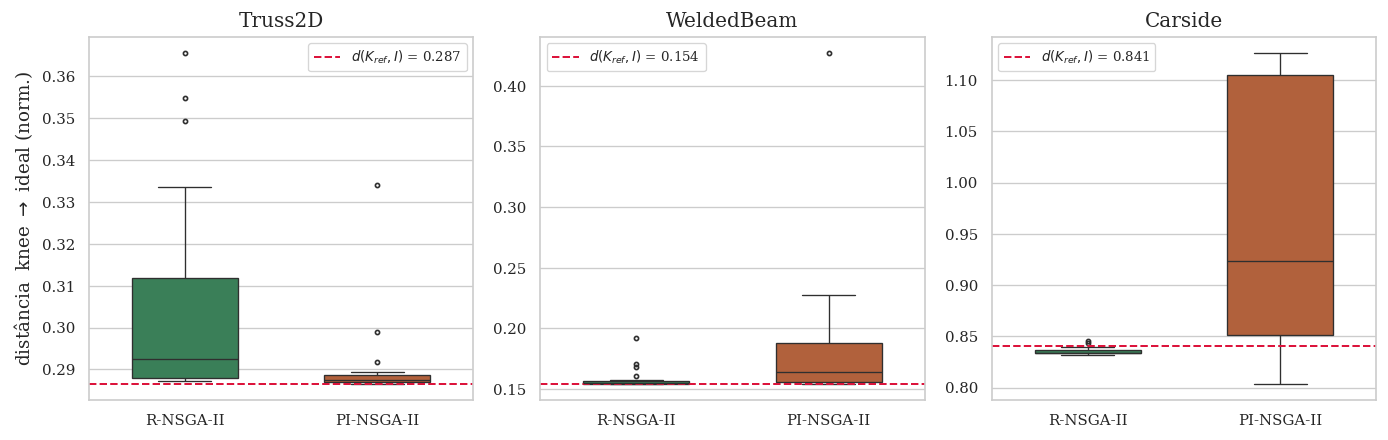

In [7]:
# ========== 2. Boxplots (publicação) ==========
reg = []
for nome in PROBLEMAS:
    for alg in ["R-NSGA-II", "PI-NSGA-II"]:
        for v in dists[nome][alg]:
            reg.append({"Problema": nome, "Algoritmo": alg, "dist": v})
long = pd.DataFrame(reg)

fig, axes = plt.subplots(1, len(PROBLEMAS), figsize=(3.9*len(PROBLEMAS), 3.8))
axes = np.atleast_1d(axes)
for ax, nome in zip(axes, PROBLEMAS):
    sub = long[long["Problema"] == nome]
    sns.boxplot(data=sub, x="Algoritmo", y="dist", hue="Algoritmo",
                order=["R-NSGA-II", "PI-NSGA-II"], palette=COR,
                ax=ax, width=.55, linewidth=.8, fliersize=2.5, legend=False)
    ax.axhline(dists[nome]["d_ref"], color="crimson", ls="--", lw=1.2,
               label=f"$d(K_{{ref}}, I)$ = {dists[nome]['d_ref']:.3f}")
    ax.set_title(nome); ax.set_xlabel(""); ax.legend(fontsize=8, loc="best")
axes[0].set_ylabel(r"distância  knee $\rightarrow$ ideal (norm.)")
for ax in axes[1:]: ax.set_ylabel("")
fig.tight_layout(); salvar(fig, "boxplot_distancias_enmc"); plt.show()

## 3. Curvas de Pareto com $K_{ref}$, knees e ideal

salvo: figuras\frentes_enmc_Truss2D.pdf


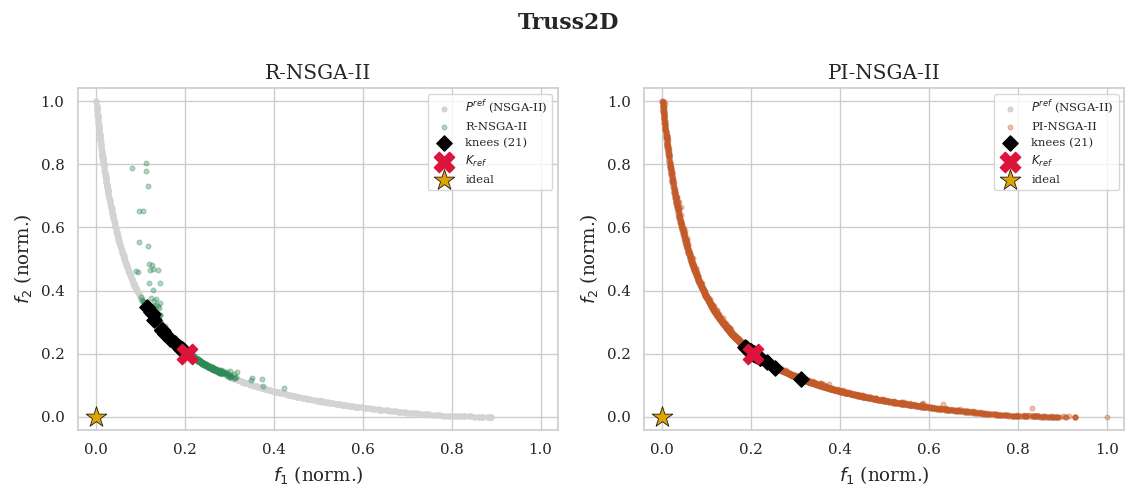

salvo: figuras\frentes_enmc_WeldedBeam.pdf


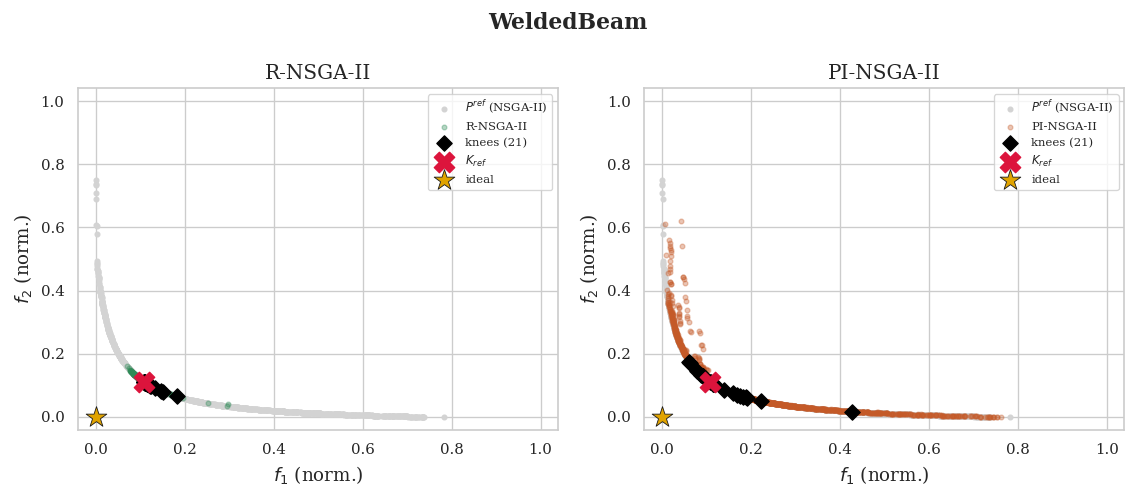

salvo: figuras\frentes_enmc_Carside.pdf


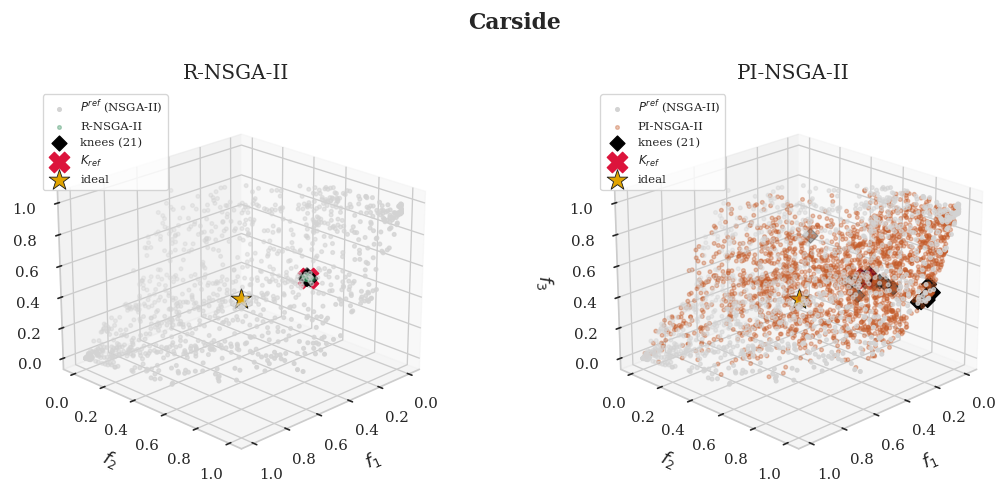

In [8]:
# ========== 3. Curvas de Pareto com K_ref, os 21 knees e o ideal ==========
def plot_frentes(nome):
    m = exp[nome]; ideal_g, nadir_g = m["ideal_g"], m["nadir_g"]
    P_ref = normalizar(m["P_ref"], ideal_g, nadir_g)
    Kr    = normalizar(m["K_ref"], ideal_g, nadir_g).ravel()
    n_obj = m["dim"]

    fig = plt.figure(figsize=(9.6, 4.2))
    for i, alg in enumerate(["R-NSGA-II", "PI-NSGA-II"], 1):
        ax = fig.add_subplot(1, 2, i, projection="3d" if n_obj >= 3 else None)
        Fn = normalizar(np.vstack(m[alg]), ideal_g, nadir_g)
        Ks = normalizar(np.vstack(m["knees"][alg]), ideal_g, nadir_g)
        if n_obj >= 3:
            ax.scatter(P_ref[:,0], P_ref[:,1], P_ref[:,2], s=5, c="lightgray", label=r"$P^{ref}$ (NSGA-II)")
            ax.scatter(Fn[:,0], Fn[:,1], Fn[:,2], s=5, color=COR[alg], alpha=.35, label=alg)
            ax.scatter(Ks[:,0], Ks[:,1], Ks[:,2], s=40, c="black", marker="D", label="knees (21)")
            ax.scatter(*Kr[:3], s=150, c="crimson", marker="X", label=r"$K_{ref}$")
            ax.scatter(0, 0, 0, s=170, c="#E0A300", marker="*", edgecolor="k", lw=.5, label="ideal")
            ax.view_init(elev=22, azim=45)
            ax.set_xlabel(r"$f_1$"); ax.set_ylabel(r"$f_2$"); ax.set_zlabel(r"$f_3$")
        else:
            ax.scatter(P_ref[:,0], P_ref[:,1], s=8, c="lightgray", label=r"$P^{ref}$ (NSGA-II)")
            ax.scatter(Fn[:,0], Fn[:,1], s=8, color=COR[alg], alpha=.35, label=alg)
            ax.scatter(Ks[:,0], Ks[:,1], s=42, c="black", marker="D", label="knees (21)")
            ax.scatter(Kr[0], Kr[1], s=150, c="crimson", marker="X", label=r"$K_{ref}$")
            ax.scatter(0, 0, s=170, c="#E0A300", marker="*", edgecolor="k", lw=.5, label="ideal")
            ax.set_xlim(-.04, 1.04); ax.set_ylim(-.04, 1.04)
            ax.set_xlabel(r"$f_1$ (norm.)"); ax.set_ylabel(r"$f_2$ (norm.)")
        ax.set_title(alg); ax.legend(fontsize=7, loc="best")
    fig.suptitle(nome, fontweight="bold"); fig.tight_layout()
    return fig

for nome in PROBLEMAS:
    fig = plot_frentes(nome)
    salvar(fig, f"frentes_enmc_{nome}"); plt.show()

[Imagens para ARTIGO]:

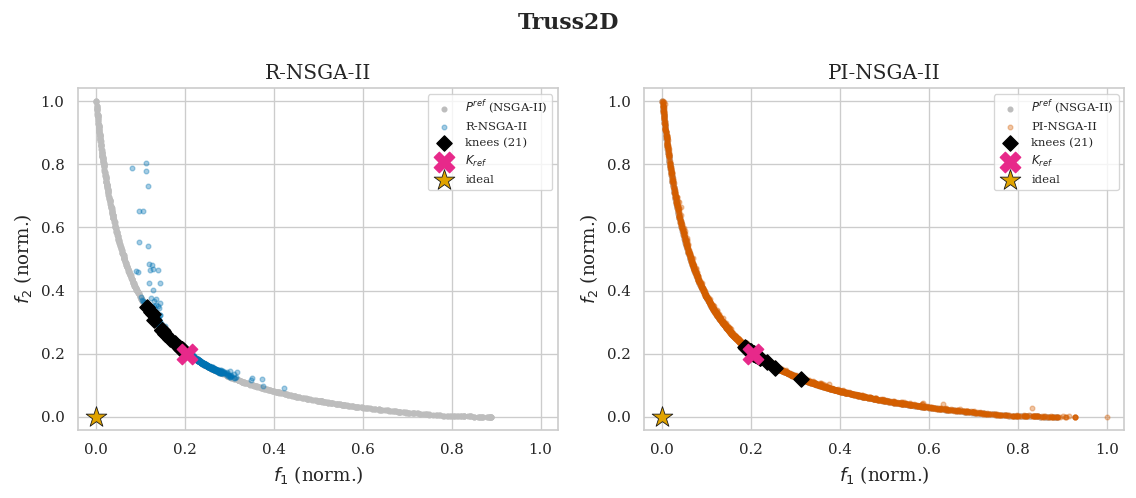

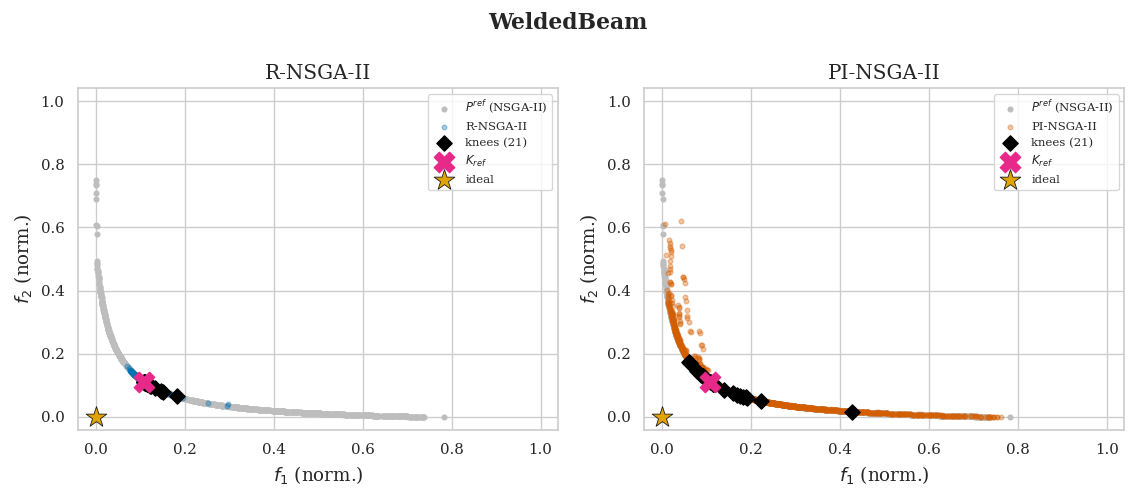

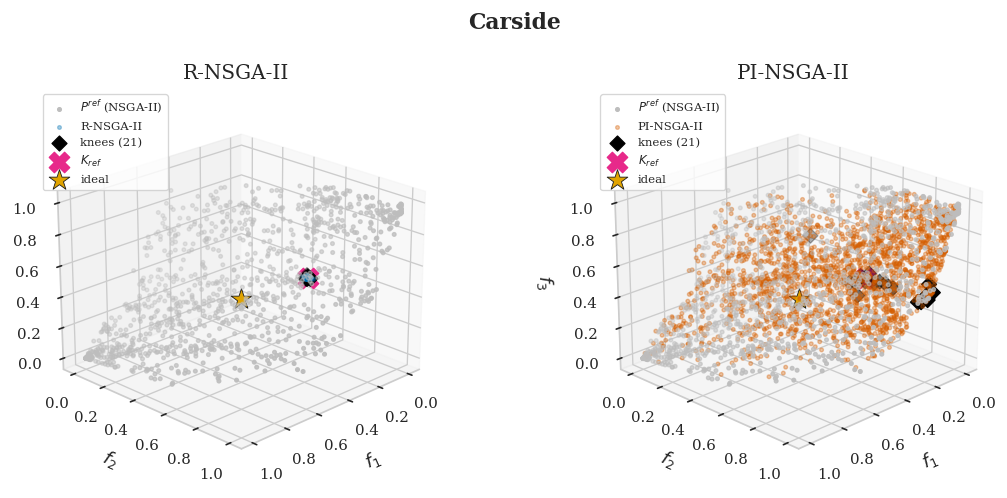

In [9]:
# Paleta e constantes de cor vêm da célula de setup (não redefinir aqui).

# ========== 3. Curvas de Pareto com K_ref, os 21 knees e o ideal ==========
def plot_frentes(nome):
    m = exp[nome]; ideal_g, nadir_g = m["ideal_g"], m["nadir_g"]
    P_ref = normalizar(m["P_ref"], ideal_g, nadir_g)
    Kr    = normalizar(m["K_ref"], ideal_g, nadir_g).ravel()
    n_obj = m["dim"]

    fig = plt.figure(figsize=(9.6, 4.2))
    for i, alg in enumerate(["R-NSGA-II", "PI-NSGA-II"], 1):
        ax = fig.add_subplot(1, 2, i, projection="3d" if n_obj >= 3 else None)
        Fn = normalizar(np.vstack(m[alg]), ideal_g, nadir_g)
        Ks = normalizar(np.vstack(m["knees"][alg]), ideal_g, nadir_g)
        if n_obj >= 3:
            ax.scatter(P_ref[:,0], P_ref[:,1], P_ref[:,2], s=5, c=C_REF, label=r"$P^{ref}$ (NSGA-II)")
            ax.scatter(Fn[:,0], Fn[:,1], Fn[:,2], s=5, color=COR[alg], alpha=.35, label=alg)
            ax.scatter(Ks[:,0], Ks[:,1], Ks[:,2], s=40, c=C_KNEE, marker="D", label="knees (21)")
            ax.scatter(*Kr[:3], s=150, c=C_KREF, marker="X", label=r"$K_{ref}$")
            ax.scatter(0, 0, 0, s=170, c=C_IDEAL, marker="*", edgecolor="k", lw=.5, label="ideal")
            ax.view_init(elev=22, azim=45)
            ax.set_xlabel(r"$f_1$"); ax.set_ylabel(r"$f_2$"); ax.set_zlabel(r"$f_3$")
        else:
            ax.scatter(P_ref[:,0], P_ref[:,1], s=8, c=C_REF, label=r"$P^{ref}$ (NSGA-II)")
            ax.scatter(Fn[:,0], Fn[:,1], s=8, color=COR[alg], alpha=.35, label=alg)
            ax.scatter(Ks[:,0], Ks[:,1], s=42, c=C_KNEE, marker="D", label="knees (21)")
            ax.scatter(Kr[0], Kr[1], s=150, c=C_KREF, marker="X", label=r"$K_{ref}$")
            ax.scatter(0, 0, s=170, c=C_IDEAL, marker="*", edgecolor="k", lw=.5, label="ideal")
            ax.set_xlim(-.04, 1.04); ax.set_ylim(-.04, 1.04)
            ax.set_xlabel(r"$f_1$ (norm.)"); ax.set_ylabel(r"$f_2$ (norm.)")
        ax.set_title(alg); ax.legend(fontsize=7, loc="best")
    fig.suptitle(nome, fontweight="bold"); fig.tight_layout()
    return fig

for nome in PROBLEMAS:
    fig = plot_frentes(nome)
    # salva vetorial em PDF, no mesmo padrão do exemplo (pronto pro Overleaf)
    fig.savefig(f"frentes_enmc_{nome}.pdf", format="pdf",
                dpi=300, bbox_inches="tight", pad_inches=0)
    plt.show()
    plt.close(fig)   # opcional: libera memória ao gerar vários PDFs no loop

## 4. Concentração em torno de $K_{ref}$

,Problema,Algoritmo,Média,DP,Mín,Máx
0,Carside,NSGA-II,0.5373,0.0151,0.5049,0.5615
1,Carside,PI-NSGA-II,0.3701,0.0964,0.2037,0.5489
2,Carside,R-NSGA-II,0.0080,0.0005,0.0068,0.0088
3,Truss2D,NSGA-II,0.3766,0.0107,0.3561,0.3937
4,Truss2D,PI-NSGA-II,0.2681,0.1023,0.0440,0.4191
5,Truss2D,R-NSGA-II,0.0246,0.0041,0.0172,0.0321
6,WeldedBeam,NSGA-II,0.2517,0.0232,0.2209,0.3011
7,WeldedBeam,PI-NSGA-II,0.1272,0.0911,0.0062,0.3538
8,WeldedBeam,R-NSGA-II,0.0090,0.0015,0.0062,0.0111


salvo: figuras\concentracao_kref_enmc.pdf


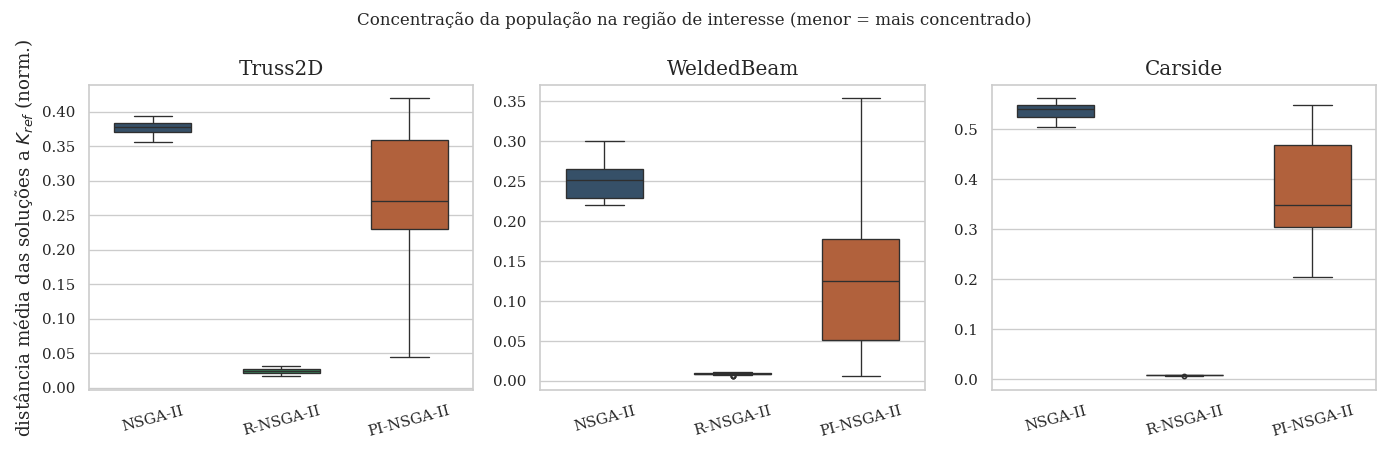

In [8]:
# ========== 4. Concentração em torno de K_ref (refinamento do orientador) ==========
# Distância média das soluções de cada frente a K_ref: separa POSIÇÃO do knee de
# CONCENTRAÇÃO da população na região de interesse.
reg = []
for nome in PROBLEMAS:
    m = exp[nome]
    Kr = normalizar(m["K_ref"], m["ideal_g"], m["nadir_g"]).ravel()
    for alg in ["NSGA-II", "R-NSGA-II", "PI-NSGA-II"]:
        for run, F in enumerate(m[alg]):
            Fn = normalizar(F, m["ideal_g"], m["nadir_g"])
            reg.append({"Problema": nome, "Algoritmo": alg, "run": run,
                        "conc": float(np.linalg.norm(Fn - Kr, axis=1).mean())})
conc = pd.DataFrame(reg)

tabc = (conc.groupby(["Problema", "Algoritmo"])["conc"]
        .agg(Média="mean", DP="std", Mín="min", Máx="max").round(4).reset_index())
display(tabc)
tabc.to_latex(PASTA_FIG / "tabela_concentracao_enmc.tex", index=False, escape=False)

fig, axes = plt.subplots(1, len(PROBLEMAS), figsize=(3.9*len(PROBLEMAS), 3.8))
axes = np.atleast_1d(axes)
ordem = ["NSGA-II", "R-NSGA-II", "PI-NSGA-II"]
for ax, nome in zip(axes, PROBLEMAS):
    sub = conc[conc["Problema"] == nome]
    sns.boxplot(data=sub, x="Algoritmo", y="conc", hue="Algoritmo", order=ordem,
                palette=COR, ax=ax, width=.6, linewidth=.8, fliersize=2.5, legend=False)
    ax.set_title(nome); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=15)
axes[0].set_ylabel(r"distância média das soluções a $K_{ref}$ (norm.)")
for ax in axes[1:]: ax.set_ylabel("")
fig.suptitle("Concentração da população na região de interesse (menor = mais concentrado)",
             fontsize=10)
fig.tight_layout(); salvar(fig, "concentracao_kref_enmc"); plt.show()

Outro boxplot para artigo:

In [ ]:
# CORRIGIDO: as chaves tinham sufixo "-BOXPLOT", que não existe na coluna
# "Algoritmo" do DataFrame conc — o seaborn renderizava categorias vazias.
# A paleta agora vem da célula de setup.

fig, axes = plt.subplots(1, len(PROBLEMAS), figsize=(3.9*len(PROBLEMAS), 3.8))
axes = np.atleast_1d(axes)
ordem = ["NSGA-II", "R-NSGA-II", "PI-NSGA-II"]
for ax, nome in zip(axes, PROBLEMAS):
    sub = conc[conc["Problema"] == nome]
    sns.boxplot(data=sub, x="Algoritmo", y="conc", hue="Algoritmo", order=ordem,
                palette=COR, ax=ax, width=.6, linewidth=.8, fliersize=2.5, legend=False)
    ax.set_title(nome); ax.set_xlabel("")
    ax.yaxis.grid(True, linewidth=.4, alpha=.4); ax.set_axisbelow(True)  # grade horizontal leve
    sns.despine(ax=ax)                                                   # tira bordas de cima/direita
axes[0].set_ylabel(r"distância média a $K_{ref}$ (norm.)")
for ax in axes[1:]: ax.set_ylabel("")
fig.tight_layout()

fig.savefig("concentracao_kref_enmc.pdf", format="pdf",
            dpi=300, bbox_inches="tight", pad_inches=0)
plt.show(); plt.close(fig)

## 5. HV e IGD na caixinha (região de interesse)

### Diagnóstico da definição de ROI *(rodar antes de refazer a Tabela 4)*

In [ ]:
# ========== DIAGNÓSTICO: a "caixinha" antiga continha o K_ref? ==========
# A versão anterior da Tabela 4 definia ROI = caixa de lado 0,25 a partir do IDEAL.
# Como a premissa do artigo é ROI = vizinhança do KNEE, é preciso verificar se o
# K_ref sequer caía dentro dessa caixa. Guarde esta saída: é a justificativa da
# mudança de definição (e do novo conjunto de números da Tabela 4).
DELTA_ANTIGO = 0.25
print(f'Caixa antiga: [0, {DELTA_ANTIGO}]^M a partir do IDEAL\n')
for nome in PROBLEMAS:
    m  = exp[nome]; d = m["dim"]
    Kn = normalizar(m["K_ref"], m["ideal_g"], m["nadir_g"]).ravel()
    Pn = normalizar(m["P_ref"], m["ideal_g"], m["nadir_g"])
    dentro    = bool(np.all(Kn <= DELTA_ANTIGO))
    n_ref     = int(np.sum(np.all(Pn <= DELTA_ANTIGO, axis=1)))
    max_norma = DELTA_ANTIGO * np.sqrt(d)
    print(f"{nome:11s} | K_ref norm = {np.round(Kn, 3)}")
    print(f"{'':11s} | ||K_ref|| = {np.linalg.norm(Kn):.4f} | máx. norma dentro da caixa = {max_norma:.4f}")
    print(f"{'':11s} | K_ref DENTRO da caixa? {dentro} | pts de P_ref na caixa: {n_ref}/{len(Pn)}")
    for alg in ["NSGA-II", "R-NSGA-II", "PI-NSGA-II"]:
        m_in = np.mean([np.sum(np.all(normalizar(F, m["ideal_g"], m["nadir_g"]) <= DELTA_ANTIGO, axis=1))
                        for F in m[alg]])
        print(f"{'':11s} |   {alg:11s}: {m_in:6.1f} soluções/execução dentro da caixa")
    print()

In [ ]:
# ========== 5. ROI = vizinhança do K_ref: HV e IGD ==========
# MUDANÇA CONCEITUAL IMPORTANTE (ver célula de diagnóstico acima):
# a versão anterior definia a ROI como uma caixa de lado 0,25 a partir do IDEAL.
# Isso contradiz a premissa do artigo (ROI = vizinhança do knee point) e, no Carside,
# deixava o próprio K_ref FORA da região de medição.
# Agora: hiperesfera de raio R_ROI (espaço normalizado) centrada em K_ref.
#   HV  -> soluções dentro da ROI; ponto de referência no canto "pior" (K_ref + raio)
#   IGD -> pontos de P_ref dentro da ROI como conjunto de referência
from pymoo.indicators.hv import HV
from pymoo.indicators.igd import IGD

R_ROI = 0.10          # raio da ROI — há varredura de sensibilidade na célula seguinte

def metricas_roi(raio):
    reg = []
    for nome in PROBLEMAS:
        m = exp[nome]; d = m["dim"]
        ig, ng = m["ideal_g"], m["nadir_g"]
        Kn = normalizar(m["K_ref"], ig, ng).ravel()
        Pn = normalizar(m["P_ref"], ig, ng)

        ref_igd = Pn[np.linalg.norm(Pn - Kn, axis=1) <= raio]
        tem_igd = len(ref_igd) > 0
        ind_igd = IGD(ref_igd) if tem_igd else None
        ind_hv  = HV(ref_point=Kn + raio)

        for alg in ["NSGA-II", "R-NSGA-II", "PI-NSGA-II"]:
            for run, F in enumerate(m[alg]):
                Fn     = normalizar(F, ig, ng)
                dentro = Fn[np.linalg.norm(Fn - Kn, axis=1) <= raio]
                reg.append({
                    "Problema": nome, "Algoritmo": alg, "run": run, "raio": raio,
                    "HV_ROI":  float(ind_hv(dentro)) if len(dentro) else 0.0,
                    "IGD_ROI": float(ind_igd(Fn)) if tem_igd else np.nan,
                    "pts_na_ROI": len(dentro),
                    "n_ref_ROI": len(ref_igd),
                })
    return pd.DataFrame(reg)

roi = metricas_roi(R_ROI)

tab_roi = (roi.groupby(["Problema", "Algoritmo"])
           .agg(HV_médio=("HV_ROI", "mean"),   HV_DP=("HV_ROI", "std"),
                IGD_médio=("IGD_ROI", "mean"), IGD_DP=("IGD_ROI", "std"),
                pts_médios=("pts_na_ROI", "mean"), n_ref=("n_ref_ROI", "max"))
           .round(4).reset_index())
display(tab_roi)
tab_roi.to_latex(PASTA_FIG / "tabela_roi_enmc.tex", index=False, escape=False)

# execuções que terminaram SEM nenhuma solução dentro da ROI (política a declarar no texto)
vazias = roi[roi["pts_na_ROI"] == 0].groupby(["Problema", "Algoritmo"]).size()
print("\nExecuções sem solução dentro da ROI (HV computado como 0):")
print(vazias if len(vazias) else "  nenhuma")

# Wilcoxon pareado R x PI dentro da ROI
print()
for nome in PROBLEMAS:
    sub = roi[roi["Problema"] == nome]
    r  = sub[sub["Algoritmo"] == "R-NSGA-II"].sort_values("run")
    pi = sub[sub["Algoritmo"] == "PI-NSGA-II"].sort_values("run")
    assert (r["run"].values == pi["run"].values).all(), "pareamento quebrado"
    for met in ["HV_ROI", "IGD_ROI"]:
        try:    pv = wilcoxon(r[met].values, pi[met].values)[1]
        except Exception: pv = float("nan")
        print(f"{nome:11s} {met:8s} p = {pv:.6f}")

# ---- boxplot do HV na ROI ----
fig, axes = plt.subplots(1, len(PROBLEMAS), figsize=(3.9*len(PROBLEMAS), 3.8))
axes = np.atleast_1d(axes)
ordem = ["NSGA-II", "R-NSGA-II", "PI-NSGA-II"]
for ax, nome in zip(axes, PROBLEMAS):
    sub = roi[roi["Problema"] == nome]
    sns.boxplot(data=sub, x="Algoritmo", y="HV_ROI", hue="Algoritmo", order=ordem,
                palette=COR, ax=ax, width=.6, linewidth=.8, fliersize=2.5, legend=False)
    ax.set_title(nome); ax.set_xlabel("")
    ax.yaxis.grid(True, linewidth=.4, alpha=.4); ax.set_axisbelow(True)
    sns.despine(ax=ax)
axes[0].set_ylabel(f"HV na ROI (raio {R_ROI}) — maior = melhor")
for ax in axes[1:]: ax.set_ylabel("")
fig.tight_layout()
fig.savefig(PASTA_FIG / "hv_roi_enmc.pdf", format="pdf",
            dpi=300, bbox_inches="tight", pad_inches=0)
plt.show(); plt.close(fig)

### 5b. Sensibilidade da ROI ao raio

In [ ]:
# ========== Sensibilidade da ROI ao raio ==========
# Responde de antemão ao "por que este raio?". Reporte a tabela ou ao menos
# declare no texto que a conclusão se mantém na faixa testada.
linhas = []
for raio in [0.05, 0.10, 0.20, 0.30]:
    t = (metricas_roi(raio).groupby(["Problema", "Algoritmo"])
         .agg(HV=("HV_ROI", "mean"), IGD=("IGD_ROI", "mean"),
              pts=("pts_na_ROI", "mean"), n_ref=("n_ref_ROI", "max"))
         .round(4).reset_index())
    t.insert(0, "raio", raio)
    linhas.append(t)
sens = pd.concat(linhas, ignore_index=True)
display(sens.pivot_table(index=["Problema", "Algoritmo"], columns="raio",
                         values=["HV", "IGD"]).round(4))
sens.to_csv(PASTA_FIG / "sensibilidade_roi.csv", index=False)
print("Exportado: sensibilidade_roi.csv")

## 6. Descrição dos problemas

| Problema | Origem | Variáveis | Objetivos | Restrições | Descrição |
|---|---|---|---|---|---|
| **Truss2D** | Projeto estrutural | 3 | 2 | 1 | Treliça de duas barras: minimizar volume de material e tensão na estrutura. |
| **WeldedBeam** | Projeto mecânico (Deb 1999; Ray & Liew 2002) | 4 | 2 | 4 | Viga soldada: minimizar custo de fabricação e deflexão da extremidade, sob restrições de tensão de cisalhamento, flexão e flambagem. |
| **Carside** | Segurança veicular (Youn et al. 2004, proc. EEVC) | 7 | 3 | 10 | Impacto lateral de automóvel: minimizar o peso e as métricas de dano ao ocupante sob colisão lateral. |

Toda a análise usa a **fronteira de referência empírica** $P^{ref}$ (união de 21 execuções do NSGA-II, refiltrada por não dominância) e o **ponto ideal aproximado** (mínimo por objetivo na união das 63 frentes) — aproximações empíricas, não a fronteira de Pareto verdadeira.

In [10]:
# Distância do knee da FRENTE COMBINADA de cada algoritmo ao ideal
# (nota do coorientador: "distância do ideal, frentes combinadas também")
linhas_ag = []
for nome in PROBLEMAS:
    m = exp[nome]
    for alg in ["NSGA-II", "R-NSGA-II", "PI-NSGA-II"]:
        P_comb = filtrar_nao_dominados(np.vstack(m[alg]))   # 21 frentes -> não dominados
        K_comb = knee_point(P_comb)
        linhas_ag.append({"Problema": nome, "Algoritmo": alg,
                          "d(K_combinado, I)": round(dist_ideal(nome, K_comb), 4)})
tab_ag = pd.DataFrame(linhas_ag)
display(tab_ag)
tab_ag.to_latex(PASTA_FIG / "tabela_knee_combinado_enmc.tex", index=False, escape=False)

,Problema,Algoritmo,"d(K_combinado, I)"
0,Truss2D,NSGA-II,0.2866
1,Truss2D,R-NSGA-II,0.3334
2,Truss2D,PI-NSGA-II,0.2869
3,WeldedBeam,NSGA-II,0.1545
4,WeldedBeam,R-NSGA-II,0.1698
5,WeldedBeam,PI-NSGA-II,0.1561
6,Carside,NSGA-II,0.8408
7,Carside,R-NSGA-II,0.8340
8,Carside,PI-NSGA-II,0.8420
